## Resolução do caso base

In [1]:
%%writefile conexoes.csv
Alice,Helena
Alice,Bruno
Alice,Camila
Bruno,Helena
Bruno,Carlos
Bruno,Diego
Camila,Diego
Camila,Elaine
Carlos,Daniela
Carlos,Eduardo
Carlos,Helena
Daniela,Helena
Daniela,Fabio
Diego,Helena
Diego,Gabriela
Diego,Isabela
Eduardo,Diego
Eduardo,Joao
Elaine,Helena
Elaine,Karen
Fabio,Helena
Fabio,Lucas
Gabriela,Mariana
Gabriela,Helena
Henrique,Helena
Henrique,Nicolas
Isabela,Diego
Isabela,Olivia
Joao,Pedro
Joao,Quintino
Joao,Helena
Karen,Mariana
Karen,Renata
Lucas,Helena
Lucas,Samuel
Mariana,Helena
Mariana,Tatiana
Mariana,Ulisses
Nicolas,Mariana
Nicolas,Vitoria
Olivia,Helena
Olivia,Wagner
Pedro,Diego
Pedro,Xuxa
Quintino,Helena
Quintino,Yuri
Renata,Mariana
Renata,Zara
Samuel,Helena
Samuel,Artur
Tatiana,Mariana
Tatiana,Bianca
Ulisses,Helena
Ulisses,Caio
Vitoria,Diego
Vitoria,Diana
Wagner,Helena
Wagner,Flavia
Xuxa,Mariana
Xuxa,Gustavo
Yuri,Helena
Yuri,Igor
Zara,Helena
Zara,Julia
Artur,Diego
Artur,Marcos
Bianca,Helena
Bianca,Natalia
Caio,Mariana
Caio,Otavio
Diana,Helena
Diana,Paula
Flavia,Diego
Flavia,Rafael
Gustavo,Helena
Gustavo,Thiago
Igor,Mariana
Igor,Ursula
Julia,Helena
Julia,Victor
Marcos,Diego
Marcos,Wesley
Natalia,Helena
Natalia,Ximena
Otavio,Mariana
Otavio,Yago
Paula,Helena
Paula,Alice
Rafael,Diego
Rafael,Bruno
Thiago,Helena
Thiago,Camila
Ursula,Mariana
Ursula,Carlos
Victor,Helena
Victor,Daniela
Wesley,Diego
Wesley,Eduardo
Ximena,Helena
Ximena,Elaine
Yago,Mariana
Yago,Fabio
Enzo,Kaua
Enzo,Sofia
Kaua,Enzo
Kaua,Sofia
Sofia,Kaua
Sofia,Enzo
Sofia,Helena
Alice,Mariana
Bruno,Mariana
Camila,Mariana
Carlos,Mariana
Daniela,Diego
Eduardo,Mariana
Elaine,Diego
Fabio,Diego
Gabriela,Diego
Henrique,Diego
Isabela,Mariana
Joao,Mariana
Karen,Diego
Lucas,Diego
Nicolas,Diego
Olivia,Diego
Pedro,Mariana
Quintino,Diego
Renata,Diego
Samuel,Mariana
Tatiana,Diego
Ulisses,Diego
Vitoria,Mariana
Wagner,Mariana
Xuxa,Diego
Yuri,Diego
Zara,Mariana

Overwriting conexoes.csv


## Funções necessárias

In [2]:
import numpy as np

def criar_matriz_adjacencia(nome_arquivo):
    """
    Lê o arquivo de conexões e monta a Matriz de Adjacência (A).
    A Linha é o Seguidor. A Coluna é o Seguido.

    Retorna:
        - lista_nomes: Lista de strings com os nomes ordenados alfabeticamente.
        - A: Array do numpy (Matriz Quadrada) contendo 0s e 1s.
    """
    # Lendo o arquivo e descobrindo todos os usuários únicos
    linhas_arquivo = open(nome_arquivo, 'r').read().splitlines()

    nomes_unicos = set()
    for linha in linhas_arquivo:
        seguidor, seguido = linha.split(',')
        nomes_unicos.add(seguidor)
        nomes_unicos.add(seguido)

    lista_nomes = sorted(list(nomes_unicos)) # Ordem alfabética garante os índices!
    n = len(lista_nomes)

    # Criando matriz de zeros
    A = np.zeros((n, n))

    for linha in linhas_arquivo:
        seguidor, seguido = linha.split(',')
        indice_seguidor = lista_nomes.index(seguidor)
        indice_seguido = lista_nomes.index(seguido)
        A[indice_seguidor, indice_seguido] = 1.0

    return lista_nomes, A

def calcular_influencia(A, num_iteracoes=20):
    """
    Descobre quem é o Nó Alfa.
    A influência vem de quem aponta para você (colunas).

    Retorna:
        - vetor_v: Array 1D do numpy com a nota final de influência.
    """
    n = A.shape[0]
    # Inicia com 1.0 para todo mundo
    vetor_v = np.ones(n)

    for _ in range(num_iteracoes):
        vetor_v = np.dot(A.T, vetor_v)
        norma = np.linalg.norm(vetor_v)
        if norma != 0:
            vetor_v /= norma

    return vetor_v

def gerar_matriz_pesos(A, teimosia=0.0):
    """
    Transforma a Matriz de Adjacência numa Matriz de Atenção.
    A soma de cada linha deve ser 1.0.

    Parâmetros:
        - A: Matriz de adjacência.
        - teimosia: Peso de auto-influência adicionado à diagonal.

    Retorna:
        - W: Matriz de Pesos (numpy array).
    """
    A_base = A.astype(float).copy()
    if teimosia > 0:
        np.fill_diagonal(A_base, A_base.diagonal() + teimosia)

    somas = A_base.sum(axis=1, keepdims=True)
    W = np.zeros_like(A_base, dtype=float)
    np.divide(A_base, somas, out=W, where=somas != 0)

    # Se a pessoa não segue ninguém, ela mantém 100% da própria opinião
    usuarios_sem_saida = np.where(somas.ravel() == 0)[0]
    W[usuarios_sem_saida, usuarios_sem_saida] = 1.0

    return W

def simular_contagio(W, vetor_opiniao_inicial, dias=15):
    """
    Simula o Efeito Manada ao longo do tempo.
    A opinião flui na direção que o usuário lê.
    Portanto, usamos a matriz normal W.

    Retorna:
        - historico: Matriz onde cada coluna é a opinião da rede em um dia específico.
    """
    n = W.shape[0]
    # Matriz para guardar as opiniões (linhas = usuários, colunas = dias)
    historico = np.zeros((n, dias))

    vetor_atual = vetor_opiniao_inicial.copy()

    for dia in range(dias):
        historico[:, dia] = vetor_atual
        vetor_atual = np.dot(W, vetor_atual)
    return historico

## Caso base

=== INICIANDO ANÁLISE DA REDE SOCIAL ===

 O Nó Alfa (maior influência) é: Helena!

Gerando painel de visualização...


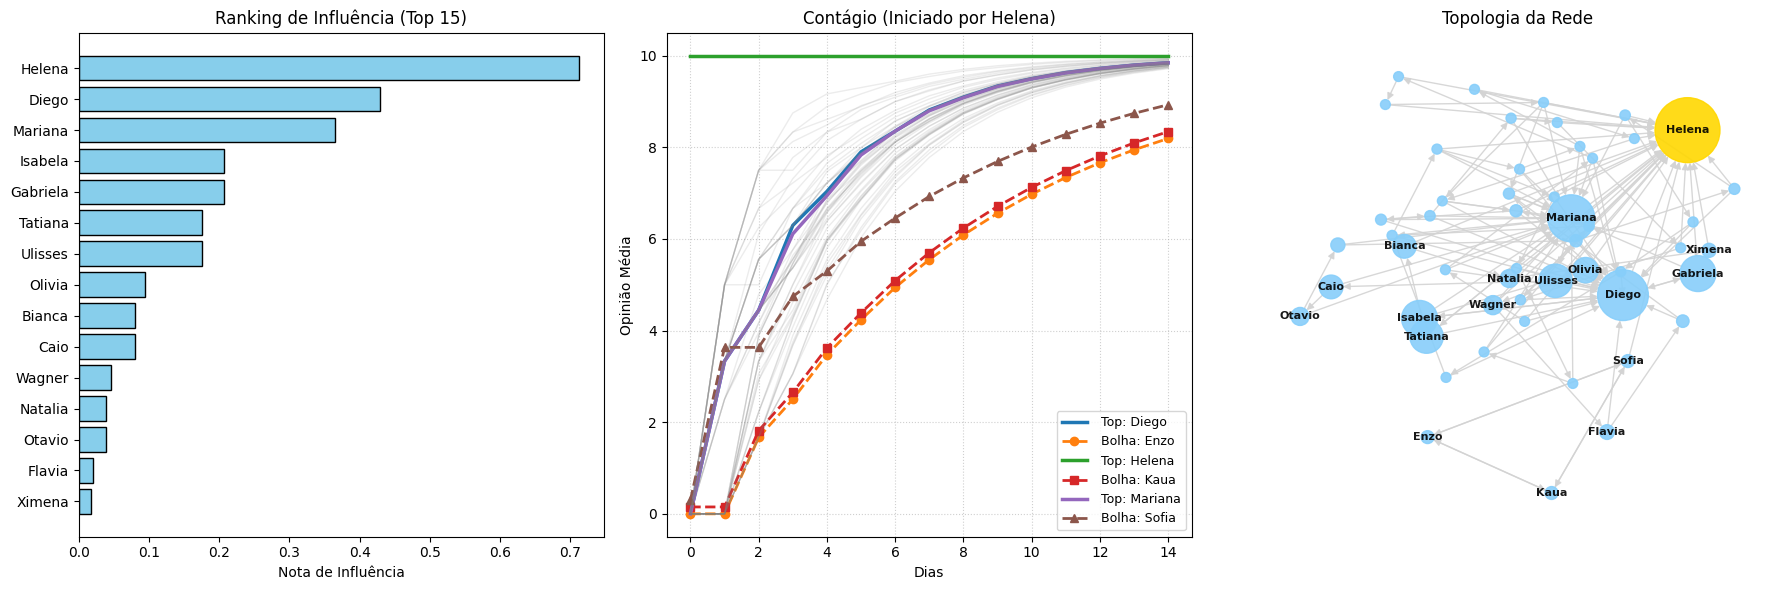

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

print("=== INICIANDO ANÁLISE DA REDE SOCIAL ===\n")

# ---------------------------------------------------------
# FASE 1: Montagem e Influência (O Nó Alfa)
# ---------------------------------------------------------

nomes, A = criar_matriz_adjacencia('conexoes.csv')

vetor_influencia = calcular_influencia(A)

indice_alfa = np.argmax(vetor_influencia)

nome_alfa = nomes[indice_alfa]
print(f" O Nó Alfa (maior influência) é: {nome_alfa}!\n")

# ---------------------------------------------------------
# FASES 2 e 3: O Simulador de Contágio
# ---------------------------------------------------------

W = gerar_matriz_pesos(A, teimosia=0)

vetor_opiniao_inicial = np.zeros(len(nomes))
vetor_opiniao_inicial[indice_alfa] = 10.0


historico = simular_contagio(W, vetor_opiniao_inicial, dias=15)
# ==========================================
# FASE 4: Visualização de Dados Profissional
# ==========================================
print("Gerando painel de visualização...")
plt.figure(figsize=(18, 6))

# --- Preparando os "Protagonistas" ---
indices_ranking = np.argsort(vetor_influencia)[::-1]
top_15_indices = indices_ranking[:15]
top_3_indices = indices_ranking[:3]

# Identificando a "Bolha" para destacar no gráfico
nomes_bolha = ["Enzo", "Kaua", "Sofia"]
indices_bolha = [nomes.index(n) for n in nomes_bolha if n in nomes]

# --- GRÁFICO 1: Ranking de Influência (Top 15) ---
plt.subplot(1, 3, 1)
nomes_top15 = [nomes[i] for i in top_15_indices]
notas_top15 = [vetor_influencia[i] for i in top_15_indices]

plt.barh(nomes_top15[::-1], notas_top15[::-1], color='skyblue', edgecolor='black')
plt.title("Ranking de Influência (Top 15)")
plt.xlabel("Nota de Influência")

# --- GRÁFICO 2: Evolução das Opiniões (Efeito Manada) ---
plt.subplot(1, 3, 2)
plt.title(f"Contágio (Iniciado por {nome_alfa})")

# Lista de marcadores para diferenciar linhas que se sobrepõem
marcadores_bolha = ['o', 's', '^']
contador_bolha = 0

for i in range(len(nomes)):
    if i in top_3_indices: # Destaca o Top 3 com linhas grossas
        plt.plot(historico[i, :], label=f" Top: {nomes[i]}", linewidth=2.5)

    elif i in indices_bolha: # Destaca a Bolha com linhas tracejadas
        # Desloca a linha 0.15 para cima a cada novo membro da bolha
        # Isso não muda a matemática, apenas "descola" as linhas no gráfico!
        deslocamento_visual = contador_bolha * 0.15

        plt.plot(historico[i, :] + deslocamento_visual, label=f" Bolha: {nomes[i]}",
                 linestyle='--', linewidth=2,
                 marker=marcadores_bolha[contador_bolha], markersize=6)
        contador_bolha += 1

    else: # O resto vira "ruído de fundo" em cinza transparente
        plt.plot(historico[i, :], color='gray', alpha=0.15, linewidth=1)

plt.xlabel("Dias")
plt.ylabel("Opinião Média")
plt.ylim(-0.5, 10.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=9)

# --- GRÁFICO 3: O Mapa da Rede (NetworkX) ---
plt.subplot(1, 3, 3)
plt.title("Topologia da Rede")

G = nx.from_numpy_array(A, create_using=nx.DiGraph)
mapeamento = {i: nomes[i] for i in range(len(nomes))}
G = nx.relabel_nodes(G, mapeamento)

# Calcula o tamanho e as cores dos nós
tamanhos = [50 + (nota * 3000) for nota in vetor_influencia]
cores = ['gold' if i == indice_alfa else 'lightskyblue' for i in range(len(nomes))]

# Filtra os rótulos para não poluir a tela
labels_filtrados = {}
for i, nome in enumerate(nomes):
    if i in top_15_indices or i in indices_bolha:
        labels_filtrados[nome] = nome
    else:
        labels_filtrados[nome] = ""

# k=0.9 afasta os nós, iterations=100 garante a estabilidade
pos = nx.spring_layout(G, k=0.9, iterations=100, seed=42)

nx.draw(G, pos, labels=labels_filtrados, node_size=tamanhos, node_color=cores,
        font_size=8, font_weight='bold', edge_color='lightgray', arrows=True, alpha=0.9)

plt.tight_layout()
plt.show()

## Experimento A

In [4]:
%%writefile conexoes2.csv
Alice,Helena
Alice,Bruno
Alice,Camila
Bruno,Helena
Bruno,Carlos
Bruno,Diego
Camila,Diego
Camila,Elaine
Carlos,Daniela
Carlos,Eduardo
Carlos,Helena
Daniela,Helena
Daniela,Fabio
Diego,Helena
Diego,Gabriela
Diego,Isabela
Eduardo,Diego
Eduardo,Joao
Elaine,Helena
Elaine,Karen
Fabio,Helena
Fabio,Lucas
Gabriela,Mariana
Gabriela,Helena
Henrique,Helena
Henrique,Nicolas
Isabela,Diego
Isabela,Olivia
Joao,Pedro
Joao,Quintino
Joao,Helena
Karen,Mariana
Karen,Renata
Lucas,Helena
Lucas,Samuel
Mariana,Helena
Mariana,Tatiana
Mariana,Ulisses
Nicolas,Mariana
Nicolas,Vitoria
Olivia,Helena
Olivia,Wagner
Pedro,Diego
Pedro,Xuxa
Quintino,Helena
Quintino,Yuri
Renata,Mariana
Renata,Zara
Samuel,Helena
Samuel,Artur
Tatiana,Mariana
Tatiana,Bianca
Ulisses,Helena
Ulisses,Caio
Vitoria,Diego
Vitoria,Diana
Wagner,Helena
Wagner,Flavia
Xuxa,Mariana
Xuxa,Gustavo
Yuri,Helena
Yuri,Igor
Zara,Helena
Zara,Julia
Artur,Diego
Artur,Marcos
Bianca,Helena
Bianca,Natalia
Caio,Mariana
Caio,Otavio
Diana,Helena
Diana,Paula
Flavia,Diego
Flavia,Rafael
Gustavo,Helena
Gustavo,Thiago
Igor,Mariana
Igor,Ursula
Julia,Helena
Julia,Victor
Marcos,Diego
Marcos,Wesley
Natalia,Helena
Natalia,Ximena
Otavio,Mariana
Otavio,Yago
Paula,Helena
Paula,Alice
Rafael,Diego
Rafael,Bruno
Thiago,Helena
Thiago,Camila
Ursula,Mariana
Ursula,Carlos
Victor,Helena
Victor,Daniela
Wesley,Diego
Wesley,Eduardo
Ximena,Helena
Ximena,Elaine
Yago,Mariana
Yago,Fabio
Enzo,Kaua
Enzo,Sofia
Kaua,Enzo
Kaua,Sofia
Sofia,Kaua
Sofia,Enzo
Sofia,Helena
Alice,Mariana
Bruno,Mariana
Camila,Mariana
Carlos,Mariana
Daniela,Diego
Eduardo,Mariana
Elaine,Diego
Fabio,Diego
Gabriela,Diego
Henrique,Diego
Isabela,Mariana
Joao,Mariana
Karen,Diego
Lucas,Diego
Nicolas,Diego
Olivia,Diego
Pedro,Mariana
Quintino,Diego
Renata,Diego
Samuel,Mariana
Tatiana,Diego
Ulisses,Diego
Vitoria,Mariana
Wagner,Mariana
Xuxa,Diego
Yuri,Diego
Zara,Mariana
Helena,Mariana
Helena,Carlos

Overwriting conexoes2.csv


=== INICIANDO ANÁLISE DA REDE SOCIAL ===

 O Nó Alfa (maior influência) é: Helena!

Gerando painel de visualização...


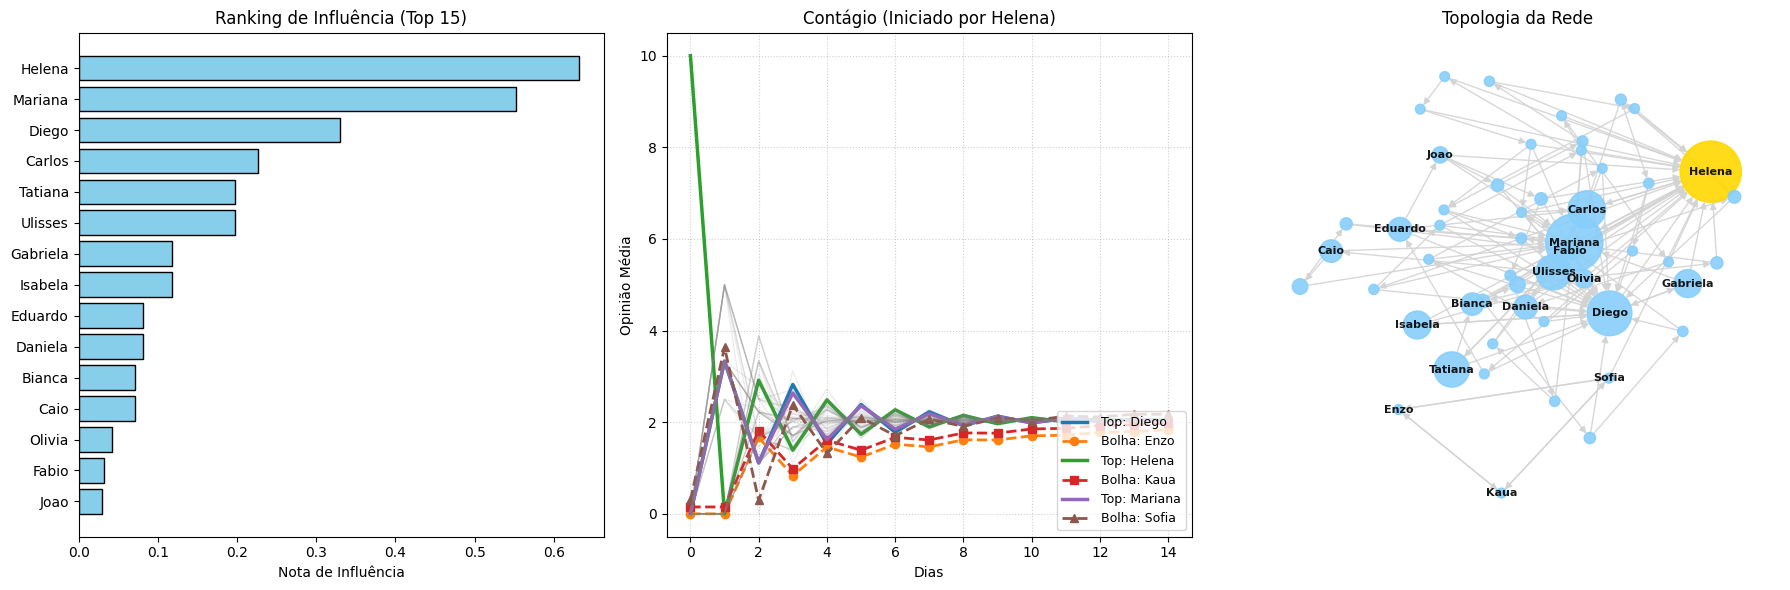

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

print("=== INICIANDO ANÁLISE DA REDE SOCIAL ===\n")

# ---------------------------------------------------------
# FASE 1: Montagem e Influência (O Nó Alfa)
# ---------------------------------------------------------

nomes, A = criar_matriz_adjacencia('conexoes2.csv')

vetor_influencia = calcular_influencia(A)

indice_alfa = np.argmax(vetor_influencia)

nome_alfa = nomes[indice_alfa]
print(f" O Nó Alfa (maior influência) é: {nome_alfa}!\n")

# ---------------------------------------------------------
# FASES 2 e 3: O Simulador de Contágio
# ---------------------------------------------------------

W = gerar_matriz_pesos(A, teimosia=0)

vetor_opiniao_inicial = np.zeros(len(nomes))
vetor_opiniao_inicial[indice_alfa] = 10.0


historico = simular_contagio(W, vetor_opiniao_inicial, dias=15)
# ==========================================
# FASE 4: Visualização de Dados Profissional
# ==========================================
print("Gerando painel de visualização...")
plt.figure(figsize=(18, 6))

# --- Preparando os "Protagonistas" ---
indices_ranking = np.argsort(vetor_influencia)[::-1]
top_15_indices = indices_ranking[:15]
top_3_indices = indices_ranking[:3]

# Identificando a "Bolha" para destacar no gráfico
nomes_bolha = ["Enzo", "Kaua", "Sofia"]
indices_bolha = [nomes.index(n) for n in nomes_bolha if n in nomes]

# --- GRÁFICO 1: Ranking de Influência (Top 15) ---
plt.subplot(1, 3, 1)
nomes_top15 = [nomes[i] for i in top_15_indices]
notas_top15 = [vetor_influencia[i] for i in top_15_indices]

plt.barh(nomes_top15[::-1], notas_top15[::-1], color='skyblue', edgecolor='black')
plt.title("Ranking de Influência (Top 15)")
plt.xlabel("Nota de Influência")

# --- GRÁFICO 2: Evolução das Opiniões (Efeito Manada) ---
plt.subplot(1, 3, 2)
plt.title(f"Contágio (Iniciado por {nome_alfa})")

# Lista de marcadores para diferenciar linhas que se sobrepõem
marcadores_bolha = ['o', 's', '^']
contador_bolha = 0

for i in range(len(nomes)):
    if i in top_3_indices: # Destaca o Top 3 com linhas grossas
        plt.plot(historico[i, :], label=f" Top: {nomes[i]}", linewidth=2.5)

    elif i in indices_bolha: # Destaca a Bolha com linhas tracejadas
        # Desloca a linha 0.15 para cima a cada novo membro da bolha
        # Isso não muda a matemática, apenas "descola" as linhas no gráfico!
        deslocamento_visual = contador_bolha * 0.15

        plt.plot(historico[i, :] + deslocamento_visual, label=f" Bolha: {nomes[i]}",
                 linestyle='--', linewidth=2,
                 marker=marcadores_bolha[contador_bolha], markersize=6)
        contador_bolha += 1

    else: # O resto vira "ruído de fundo" em cinza transparente
        plt.plot(historico[i, :], color='gray', alpha=0.15, linewidth=1)

plt.xlabel("Dias")
plt.ylabel("Opinião Média")
plt.ylim(-0.5, 10.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=9)

# --- GRÁFICO 3: O Mapa da Rede (NetworkX) ---
plt.subplot(1, 3, 3)
plt.title("Topologia da Rede")

G = nx.from_numpy_array(A, create_using=nx.DiGraph)
mapeamento = {i: nomes[i] for i in range(len(nomes))}
G = nx.relabel_nodes(G, mapeamento)

# Calcula o tamanho e as cores dos nós
tamanhos = [50 + (nota * 3000) for nota in vetor_influencia]
cores = ['gold' if i == indice_alfa else 'lightskyblue' for i in range(len(nomes))]

# Filtra os rótulos para não poluir a tela
labels_filtrados = {}
for i, nome in enumerate(nomes):
    if i in top_15_indices or i in indices_bolha:
        labels_filtrados[nome] = nome
    else:
        labels_filtrados[nome] = ""

# k=0.9 afasta os nós, iterations=100 garante a estabilidade
pos = nx.spring_layout(G, k=0.9, iterations=100, seed=42)

nx.draw(G, pos, labels=labels_filtrados, node_size=tamanhos, node_color=cores,
        font_size=8, font_weight='bold', edge_color='lightgray', arrows=True, alpha=0.9)

plt.tight_layout()
plt.show()

## Experimento B

In [6]:
%%writefile conexoes3.csv
Alice,Helena
Alice,Bruno
Alice,Camila
Bruno,Helena
Bruno,Carlos
Bruno,Diego
Camila,Diego
Camila,Elaine
Carlos,Daniela
Carlos,Eduardo
Carlos,Helena
Daniela,Helena
Daniela,Fabio
Diego,Helena
Diego,Gabriela
Diego,Isabela
Eduardo,Diego
Eduardo,Joao
Elaine,Helena
Elaine,Karen
Fabio,Helena
Fabio,Lucas
Gabriela,Mariana
Gabriela,Helena
Henrique,Helena
Henrique,Nicolas
Isabela,Diego
Isabela,Olivia
Joao,Pedro
Joao,Quintino
Joao,Helena
Karen,Mariana
Karen,Renata
Lucas,Helena
Lucas,Samuel
Mariana,Helena
Mariana,Tatiana
Mariana,Ulisses
Nicolas,Mariana
Nicolas,Vitoria
Olivia,Helena
Olivia,Wagner
Pedro,Diego
Pedro,Xuxa
Quintino,Helena
Quintino,Yuri
Renata,Mariana
Renata,Zara
Samuel,Helena
Samuel,Artur
Tatiana,Mariana
Tatiana,Bianca
Ulisses,Helena
Ulisses,Caio
Vitoria,Diego
Vitoria,Diana
Wagner,Helena
Wagner,Flavia
Xuxa,Mariana
Xuxa,Gustavo
Yuri,Helena
Yuri,Igor
Zara,Helena
Zara,Julia
Artur,Diego
Artur,Marcos
Bianca,Helena
Bianca,Natalia
Caio,Mariana
Caio,Otavio
Diana,Helena
Diana,Paula
Flavia,Diego
Flavia,Rafael
Gustavo,Helena
Gustavo,Thiago
Igor,Mariana
Igor,Ursula
Julia,Helena
Julia,Victor
Marcos,Diego
Marcos,Wesley
Natalia,Helena
Natalia,Ximena
Otavio,Mariana
Otavio,Yago
Paula,Helena
Paula,Alice
Rafael,Diego
Rafael,Bruno
Thiago,Helena
Thiago,Camila
Ursula,Mariana
Ursula,Carlos
Victor,Helena
Victor,Daniela
Wesley,Diego
Wesley,Eduardo
Ximena,Helena
Ximena,Elaine
Yago,Mariana
Yago,Fabio
Enzo,Kaua
Enzo,Sofia
Kaua,Enzo
Kaua,Sofia
Sofia,Kaua
Sofia,Enzo
Sofia,Helena
Alice,Mariana
Bruno,Mariana
Camila,Mariana
Carlos,Mariana
Daniela,Diego
Eduardo,Mariana
Elaine,Diego
Fabio,Diego
Gabriela,Diego
Henrique,Diego
Isabela,Mariana
Joao,Mariana
Karen,Diego
Lucas,Diego
Nicolas,Diego
Olivia,Diego
Pedro,Mariana
Quintino,Diego
Renata,Diego
Samuel,Mariana
Tatiana,Diego
Ulisses,Diego
Vitoria,Mariana
Wagner,Mariana
Xuxa,Diego
Yuri,Diego
Zara,Mariana
Helena,Diego

Overwriting conexoes3.csv


=== INICIANDO ANÁLISE DA REDE SOCIAL ===

 O Nó Alfa (maior influência) é: Helena!

Gerando painel de visualização...


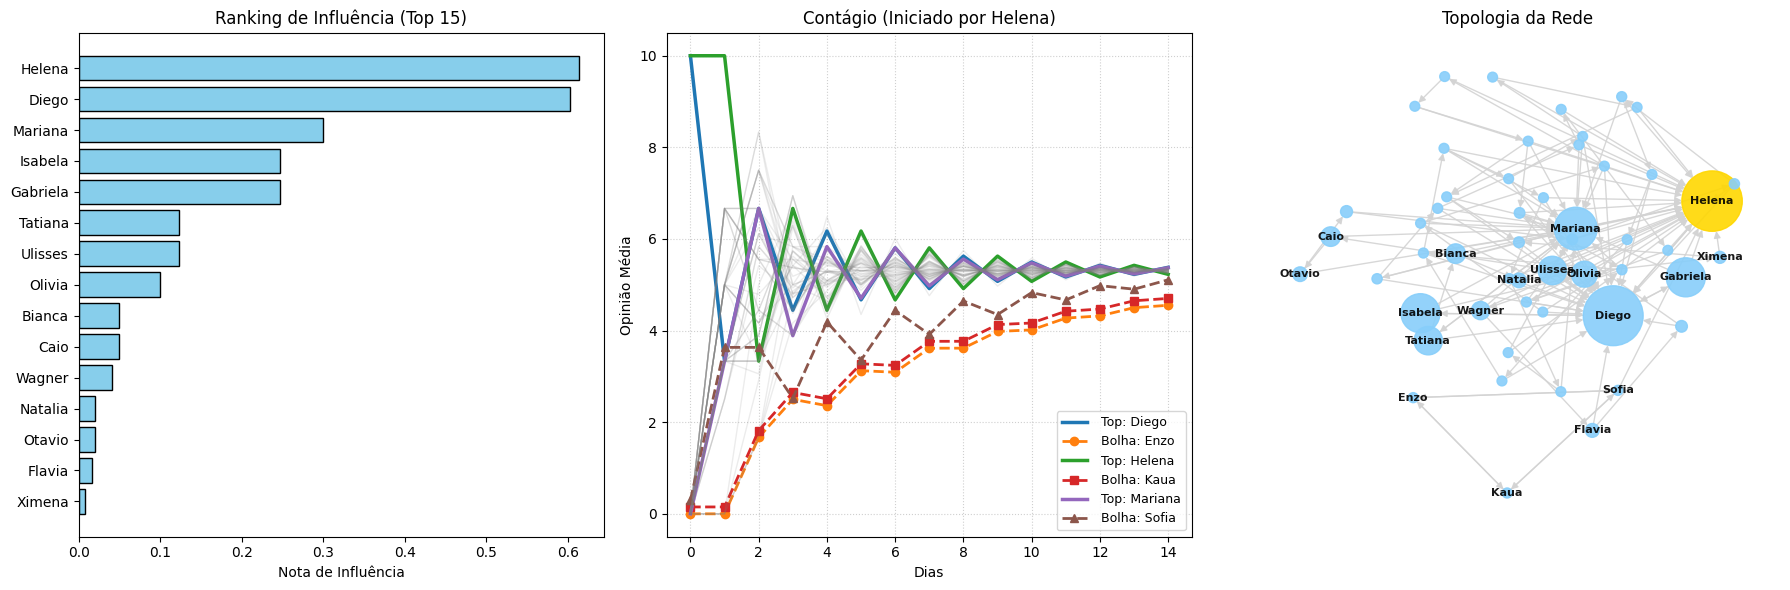

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

print("=== INICIANDO ANÁLISE DA REDE SOCIAL ===\n")

# ---------------------------------------------------------
# FASE 1: Montagem e Influência (O Nó Alfa)
# ---------------------------------------------------------

nomes, A = criar_matriz_adjacencia('conexoes3.csv')

vetor_influencia = calcular_influencia(A)

indice_alfa = np.argmax(vetor_influencia)

nome_alfa = nomes[indice_alfa]
print(f" O Nó Alfa (maior influência) é: {nome_alfa}!\n")

# ---------------------------------------------------------
# FASES 2 e 3: O Simulador de Contágio
# ---------------------------------------------------------

W = gerar_matriz_pesos(A, teimosia=0)

vetor_opiniao_inicial = np.zeros(len(nomes))
vetor_opiniao_inicial[indice_alfa] = 10.0
indice_diego = nomes.index("Diego")
vetor_opiniao_inicial[indice_diego] = 10.0

historico = simular_contagio(W, vetor_opiniao_inicial, dias=15)
# ==========================================
# FASE 4: Visualização de Dados Profissional
# ==========================================
print("Gerando painel de visualização...")
plt.figure(figsize=(18, 6))

# --- Preparando os "Protagonistas" ---
indices_ranking = np.argsort(vetor_influencia)[::-1]
top_15_indices = indices_ranking[:15]
top_3_indices = indices_ranking[:3]

# Identificando a "Bolha" para destacar no gráfico
nomes_bolha = ["Enzo", "Kaua", "Sofia"]
indices_bolha = [nomes.index(n) for n in nomes_bolha if n in nomes]

# --- GRÁFICO 1: Ranking de Influência (Top 15) ---
plt.subplot(1, 3, 1)
nomes_top15 = [nomes[i] for i in top_15_indices]
notas_top15 = [vetor_influencia[i] for i in top_15_indices]

plt.barh(nomes_top15[::-1], notas_top15[::-1], color='skyblue', edgecolor='black')
plt.title("Ranking de Influência (Top 15)")
plt.xlabel("Nota de Influência")

# --- GRÁFICO 2: Evolução das Opiniões (Efeito Manada) ---
plt.subplot(1, 3, 2)
plt.title(f"Contágio (Iniciado por {nome_alfa})")

# Lista de marcadores para diferenciar linhas que se sobrepõem
marcadores_bolha = ['o', 's', '^']
contador_bolha = 0

for i in range(len(nomes)):
    if i in top_3_indices: # Destaca o Top 3 com linhas grossas
        plt.plot(historico[i, :], label=f" Top: {nomes[i]}", linewidth=2.5)

    elif i in indices_bolha: # Destaca a Bolha com linhas tracejadas
        # Desloca a linha 0.15 para cima a cada novo membro da bolha
        # Isso não muda a matemática, apenas "descola" as linhas no gráfico!
        deslocamento_visual = contador_bolha * 0.15

        plt.plot(historico[i, :] + deslocamento_visual, label=f" Bolha: {nomes[i]}",
                 linestyle='--', linewidth=2,
                 marker=marcadores_bolha[contador_bolha], markersize=6)
        contador_bolha += 1

    else: # O resto vira "ruído de fundo" em cinza transparente
        plt.plot(historico[i, :], color='gray', alpha=0.15, linewidth=1)

plt.xlabel("Dias")
plt.ylabel("Opinião Média")
plt.ylim(-0.5, 10.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=9)

# --- GRÁFICO 3: O Mapa da Rede (NetworkX) ---
plt.subplot(1, 3, 3)
plt.title("Topologia da Rede")

G = nx.from_numpy_array(A, create_using=nx.DiGraph)
mapeamento = {i: nomes[i] for i in range(len(nomes))}
G = nx.relabel_nodes(G, mapeamento)

# Calcula o tamanho e as cores dos nós
tamanhos = [50 + (nota * 3000) for nota in vetor_influencia]
cores = ['gold' if i == indice_alfa else 'lightskyblue' for i in range(len(nomes))]

# Filtra os rótulos para não poluir a tela
labels_filtrados = {}
for i, nome in enumerate(nomes):
    if i in top_15_indices or i in indices_bolha:
        labels_filtrados[nome] = nome
    else:
        labels_filtrados[nome] = ""

# k=0.9 afasta os nós, iterations=100 garante a estabilidade
pos = nx.spring_layout(G, k=0.9, iterations=100, seed=42)

nx.draw(G, pos, labels=labels_filtrados, node_size=tamanhos, node_color=cores,
        font_size=8, font_weight='bold', edge_color='lightgray', arrows=True, alpha=0.9)

plt.tight_layout()
plt.show()

## Experimento Final

=== INICIANDO ANÁLISE DA REDE SOCIAL ===

 O Nó Alfa (maior influência) é: Helena!

Gerando painel de visualização...


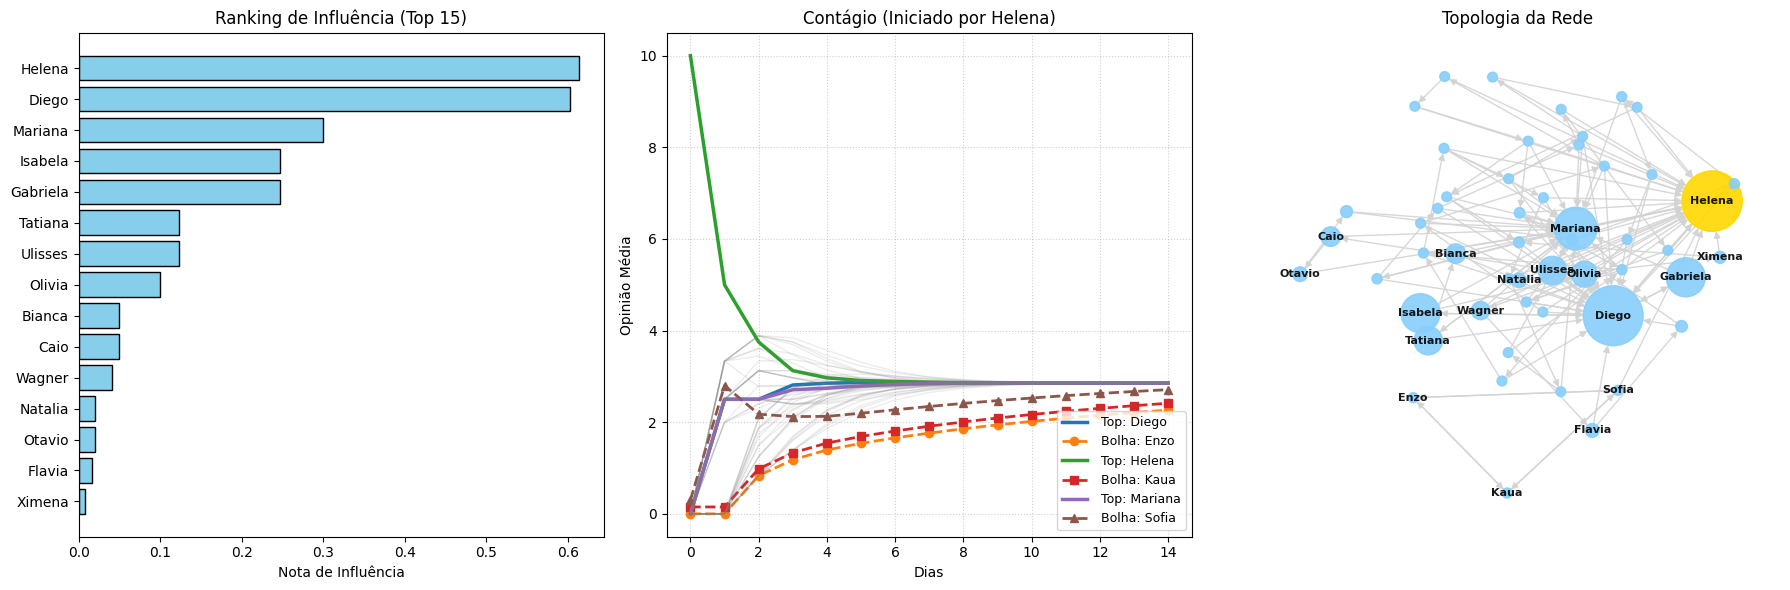

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

print("=== INICIANDO ANÁLISE DA REDE SOCIAL ===\n")

# ---------------------------------------------------------
# FASE 1: Montagem e Influência (O Nó Alfa)
# ---------------------------------------------------------

nomes, A = criar_matriz_adjacencia('conexoes3.csv')

vetor_influencia = calcular_influencia(A)

indice_alfa = np.argmax(vetor_influencia)

nome_alfa = nomes[indice_alfa]
print(f" O Nó Alfa (maior influência) é: {nome_alfa}!\n")

# ---------------------------------------------------------
# FASES 2 e 3: O Simulador de Contágio
# ---------------------------------------------------------

W = gerar_matriz_pesos(A, teimosia=1)

vetor_opiniao_inicial = np.zeros(len(nomes))
vetor_opiniao_inicial[indice_alfa] = 10.0


historico = simular_contagio(W, vetor_opiniao_inicial, dias=15)
# ==========================================
# FASE 4: Visualização de Dados Profissional
# ==========================================
print("Gerando painel de visualização...")
plt.figure(figsize=(18, 6))

# --- Preparando os "Protagonistas" ---
indices_ranking = np.argsort(vetor_influencia)[::-1]
top_15_indices = indices_ranking[:15]
top_3_indices = indices_ranking[:3]

# Identificando a "Bolha" para destacar no gráfico
nomes_bolha = ["Enzo", "Kaua", "Sofia"]
indices_bolha = [nomes.index(n) for n in nomes_bolha if n in nomes]

# --- GRÁFICO 1: Ranking de Influência (Top 15) ---
plt.subplot(1, 3, 1)
nomes_top15 = [nomes[i] for i in top_15_indices]
notas_top15 = [vetor_influencia[i] for i in top_15_indices]

plt.barh(nomes_top15[::-1], notas_top15[::-1], color='skyblue', edgecolor='black')
plt.title("Ranking de Influência (Top 15)")
plt.xlabel("Nota de Influência")

# --- GRÁFICO 2: Evolução das Opiniões (Efeito Manada) ---
plt.subplot(1, 3, 2)
plt.title(f"Contágio (Iniciado por {nome_alfa})")

# Lista de marcadores para diferenciar linhas que se sobrepõem
marcadores_bolha = ['o', 's', '^']
contador_bolha = 0

for i in range(len(nomes)):
    if i in top_3_indices: # Destaca o Top 3 com linhas grossas
        plt.plot(historico[i, :], label=f" Top: {nomes[i]}", linewidth=2.5)

    elif i in indices_bolha: # Destaca a Bolha com linhas tracejadas
        # Desloca a linha 0.15 para cima a cada novo membro da bolha
        # Isso não muda a matemática, apenas "descola" as linhas no gráfico!
        deslocamento_visual = contador_bolha * 0.15

        plt.plot(historico[i, :] + deslocamento_visual, label=f" Bolha: {nomes[i]}",
                 linestyle='--', linewidth=2,
                 marker=marcadores_bolha[contador_bolha], markersize=6)
        contador_bolha += 1

    else: # O resto vira "ruído de fundo" em cinza transparente
        plt.plot(historico[i, :], color='gray', alpha=0.15, linewidth=1)

plt.xlabel("Dias")
plt.ylabel("Opinião Média")
plt.ylim(-0.5, 10.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=9)

# --- GRÁFICO 3: O Mapa da Rede (NetworkX) ---
plt.subplot(1, 3, 3)
plt.title("Topologia da Rede")

G = nx.from_numpy_array(A, create_using=nx.DiGraph)
mapeamento = {i: nomes[i] for i in range(len(nomes))}
G = nx.relabel_nodes(G, mapeamento)

# Calcula o tamanho e as cores dos nós
tamanhos = [50 + (nota * 3000) for nota in vetor_influencia]
cores = ['gold' if i == indice_alfa else 'lightskyblue' for i in range(len(nomes))]

# Filtra os rótulos para não poluir a tela
labels_filtrados = {}
for i, nome in enumerate(nomes):
    if i in top_15_indices or i in indices_bolha:
        labels_filtrados[nome] = nome
    else:
        labels_filtrados[nome] = ""

# k=0.9 afasta os nós, iterations=100 garante a estabilidade
pos = nx.spring_layout(G, k=0.9, iterations=100, seed=42)

nx.draw(G, pos, labels=labels_filtrados, node_size=tamanhos, node_color=cores,
        font_size=8, font_weight='bold', edge_color='lightgray', arrows=True, alpha=0.9)

plt.tight_layout()
plt.show()

# Relatório Final: Influência e Contágio em Rede Social

## Introdução
Neste trabalho, modelamos uma rede social por meio de matrizes para responder a duas perguntas centrais: (i) quem concentra mais influência na rede e (ii) como uma opinião inicial se propaga ao longo do tempo. A modelagem foi feita com a matriz de adjacência $A$, a matriz de pesos $W$ e atualizações iterativas dos vetores de influência e de opinião.

## 1. A Lógica da Influência
A fase de influência usa a iteração
$$
\mathbf{v}_{k+1}=\frac{A^T\mathbf{v}_k}{\lVert A^T\mathbf{v}_k\rVert_2},
$$
com $\mathbf{v}_0=\mathbf{1}$. Essa multiplicação repetida representa, no mundo real, o fluxo acumulado de atenção: cada usuário recebe peso de quem aponta para ele, e esse peso também carrega a importância de quem o segue.

A Helena terminou como Nó Alfa porque muitas arestas chegam até ela e, além disso, parte relevante de quem aponta para ela também está em posições centrais da rede. Portanto, ela recebe influência direta e indireta, o que eleva seu valor no vetor estabilizado.

## 2. O Peso da Convicção (Diagonal Principal)
No experimento final, adicionamos teimosia ao modelo com a diagonal principal:
$$
A_{\text{teimosa}} = A + \alpha I,
$$
e depois normalizamos por linha para obter $W$. Isso significa que cada pessoa passa a considerar também a própria opinião ao calcular a média ponderada.

Em termos comportamentais, a diagonal representa convicção própria: a pessoa não muda totalmente de ideia apenas por seguir outras contas. Matematicamente, essa auto-influência reduz quedas bruscas, como a da Helena, pois parte da nota anterior permanece em cada passo da dinâmica.

## 3. A Vulnerabilidade do Ídolo (Experimento A)
A dinâmica de opinião segue
$$
\mathbf{x}_{t+1}=W\mathbf{x}_t.
$$
Quando a Helena passa a seguir usuários com opinião inicial baixa (ou zero), sua linha em $W$ redistribui atenção para esses perfis. Assim, no primeiro passo, sua nova opinião vira a média ponderada dessas fontes, que é baixa:
$$
x_H(t+1)=\sum_j W_{Hj}x_j(t) \approx 0.
$$

Com a principal fonte inicial, de nota 10, enfraquecida logo no início, o restante da rede deixa de receber um sinal forte, e o contágio global falha.

## 4. A Câmara de Eco (Experimento B)
No experimento B, forma-se um núcleo de realimentação entre perfis de alta opinião, Helena e Diego, com ambos iniciando com nota 10. Esse arranjo cria um circuito de reforço: cada um passa a receber parte relevante da massa de opinião do outro, mantendo valores altos por mais tempo.

Em linguagem de sistemas dinâmicos, existe um subgrafo com forte acoplamento interno, no qual a massa de opinião circula e se dissipa mais lentamente para o restante da rede. Em redes sociais reais, o risco é a polarização: grupos fechados reforçam crenças internas e reduzem a exposição a informações divergentes.

## 5. Equivalência Estrutural
Para duas pessoas terem curvas rigorosamente idênticas em todos os dias, o algoritmo precisa aplicar exatamente a mesma regra de atualização a ambas. Isso ocorre quando:

1. as linhas correspondentes em $W$ são iguais, com os mesmos seguidos e os mesmos pesos; e
2. as condições iniciais dessas duas pessoas são iguais.

Se essas condições valem, então para todo $t$:
$$
x_i(t+1)=\sum_j W_{ij}x_j(t)=\sum_j W_{kj}x_j(t)=x_k(t+1),
$$
logo as trajetórias coincidem em todos os instantes.

## Conclusão
A análise mostra que influência estrutural e propagação de opinião são conceitos relacionados, mas não idênticos. Um nó pode ser extremamente influente no sentido de centralidade e, ainda assim, perder rapidamente sua opinião no modelo de médias se não tiver convicção própria ou apoio recíproco. A inclusão da diagonal principal torna a dinâmica mais realista ao representar a resistência individual a mudanças abruptas.